In [7]:
# GPU kontrolü
!nvidia-smi

Tue Jun 23 13:01:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
# 1️ YOLOv8 kurulumu
!pip install -q ultralytics

In [9]:
# 2️ Kütüphaneleri içe aktar
import ultralytics
from ultralytics import YOLO
ultralytics.checks()            # versiyon / ortam bilgisi

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


In [10]:
# 3️ Veri setini indir ve çıkar
!wget -q https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip
!mkdir -p datasets
!unzip -q brain-tumor.zip -d datasets/
!rm brain-tumor.zip

replace datasets/images/train/00054_145.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace datasets/images/train/00054_164.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace datasets/images/train/00056_110.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace datasets/images/train/00056_110.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace datasets/images/train/00056_129.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [12]:
# 4️ Modeli eğit
model = YOLO("yolov8n.pt")       # ister yolov8s.pt, yolov8m.pt vb. kullanın
model.train(
    data="datasets/brain-tumor.yaml",   # zip’ten çıkan hazır YAML
    epochs=50,
    imgsz=640,
    batch=16,
    optimizer="AdamW",
    project="brain_tumor_yolov8",
    name="yolov8n_transfer",
    amp=True
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/brain-tumor.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_transfer-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pat

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b9a8184ab70>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804


1. KARIŞIKLIK MATRİSİ (CONFUSION MATRIX)
------------------------------------------------------------


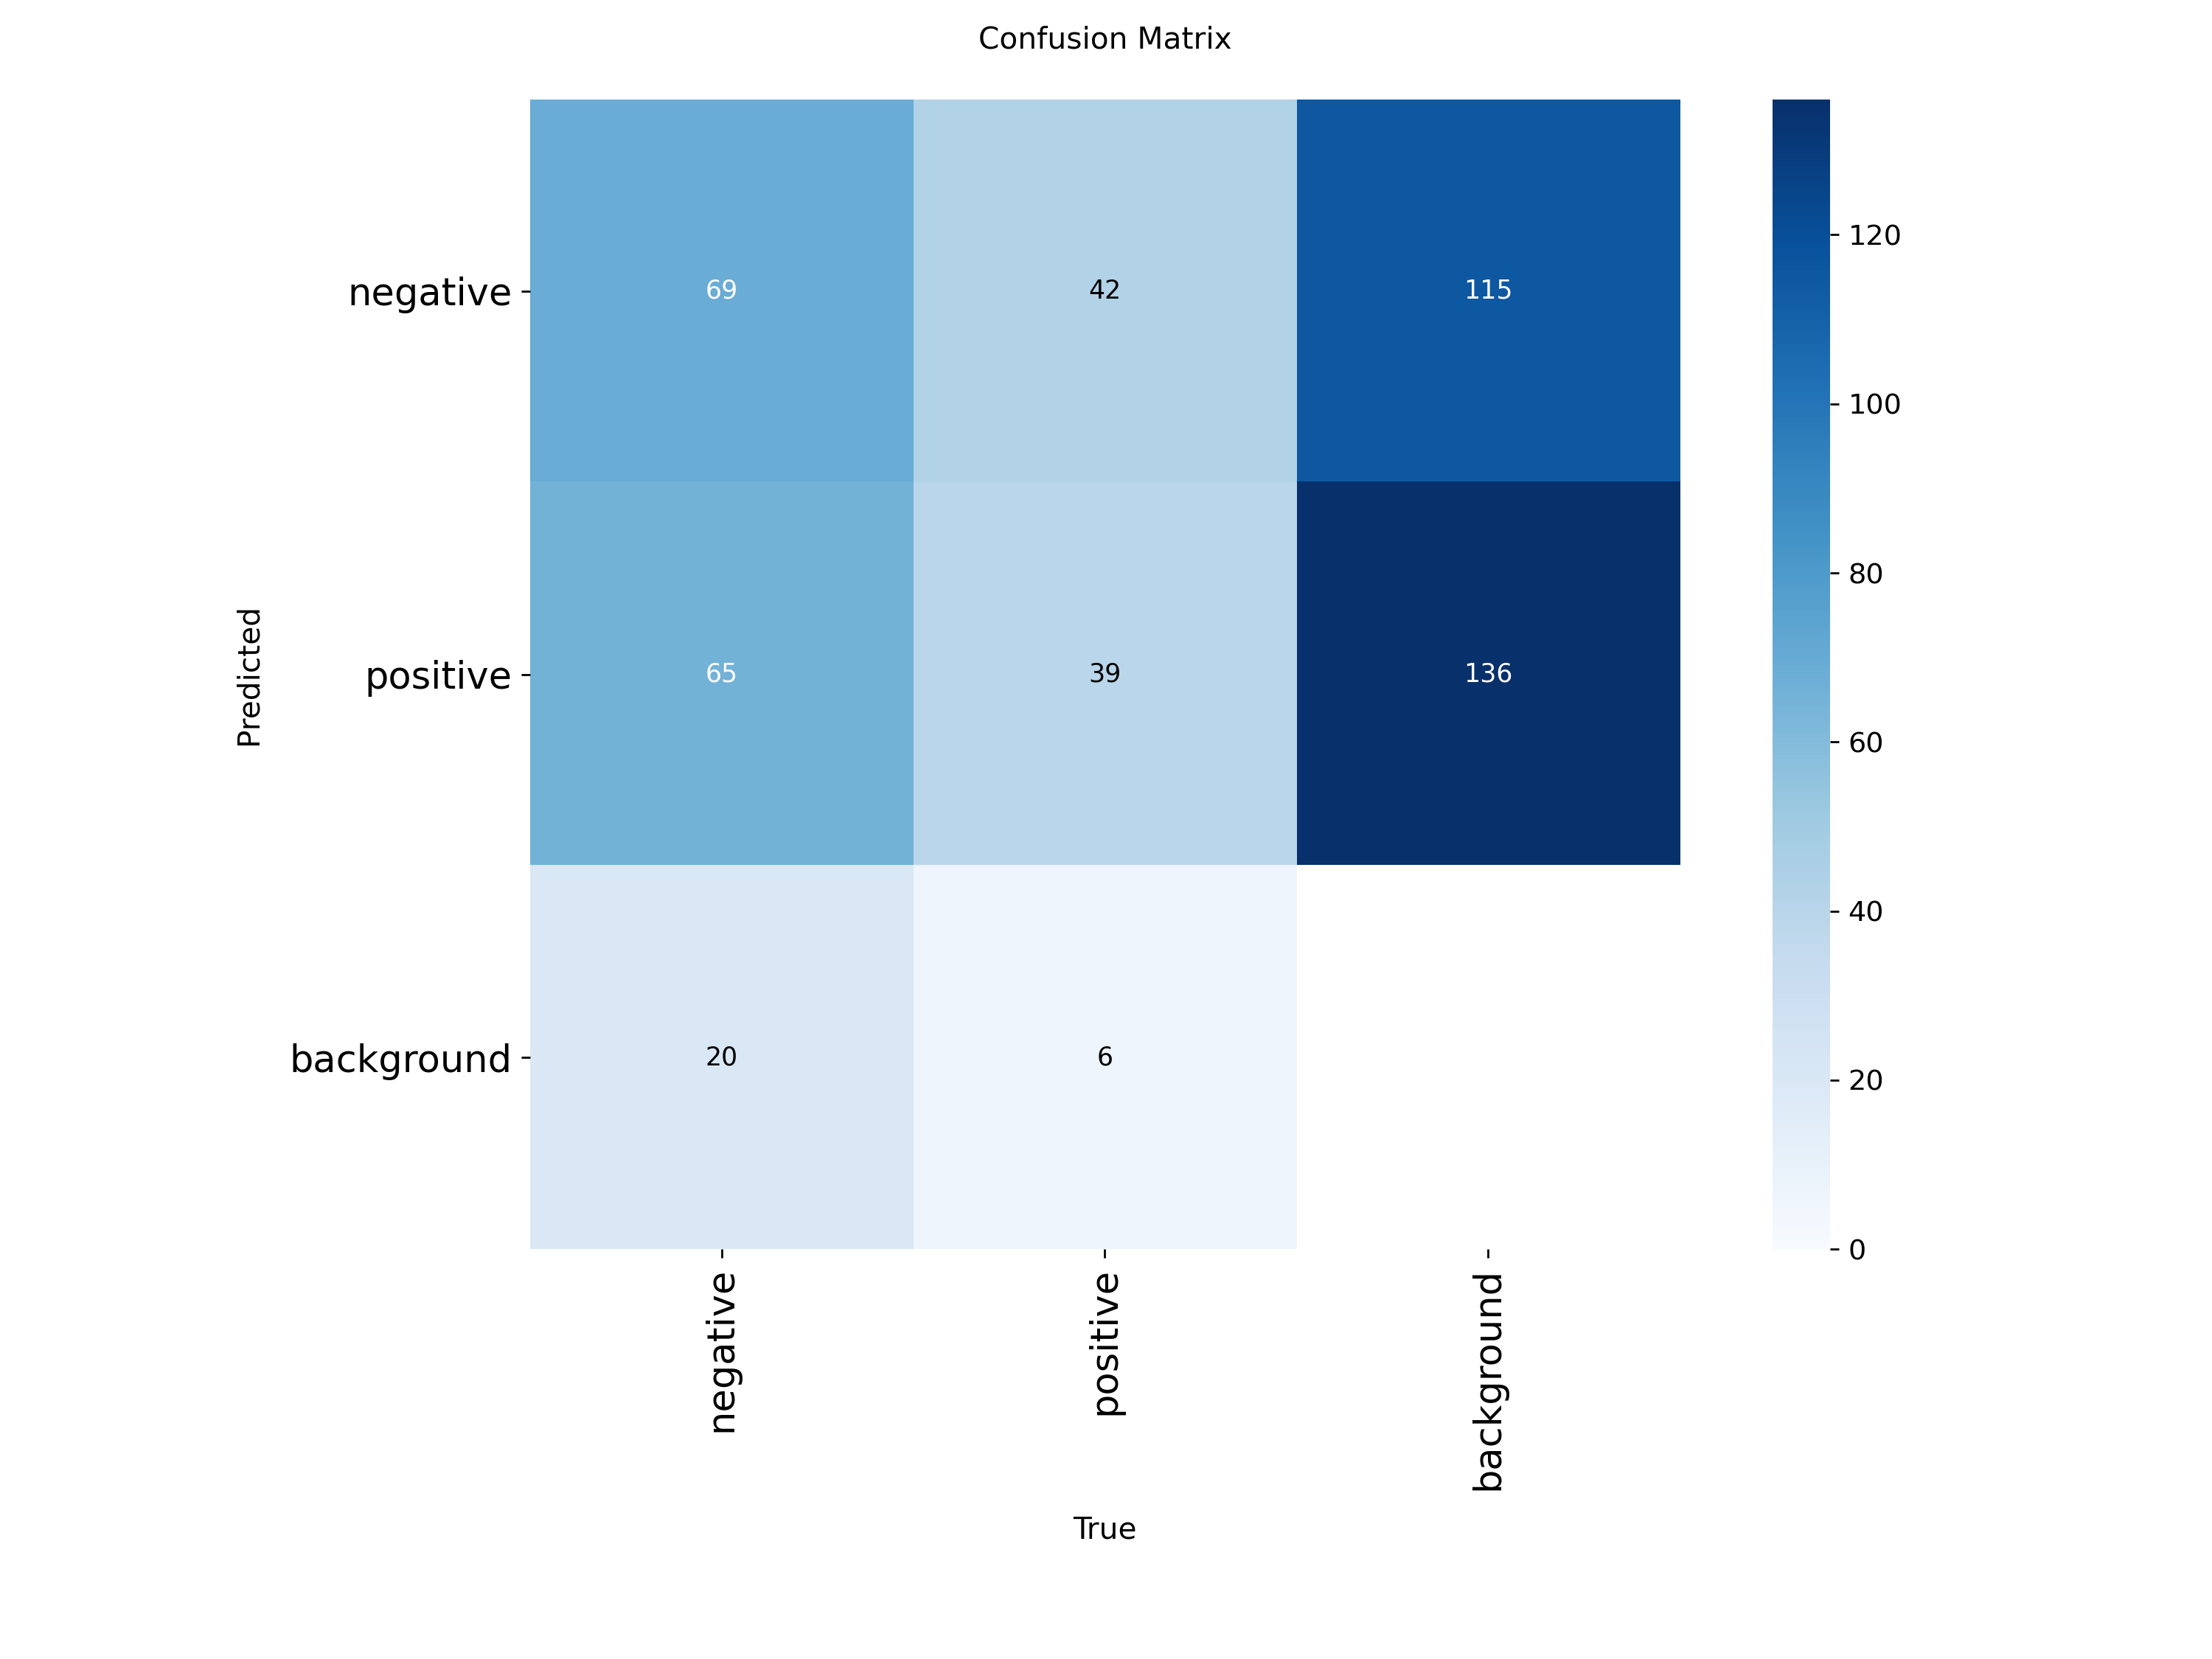


2. KESİNLİK-DUYARLILIK (PR) EĞRİSİ
------------------------------------------------------------


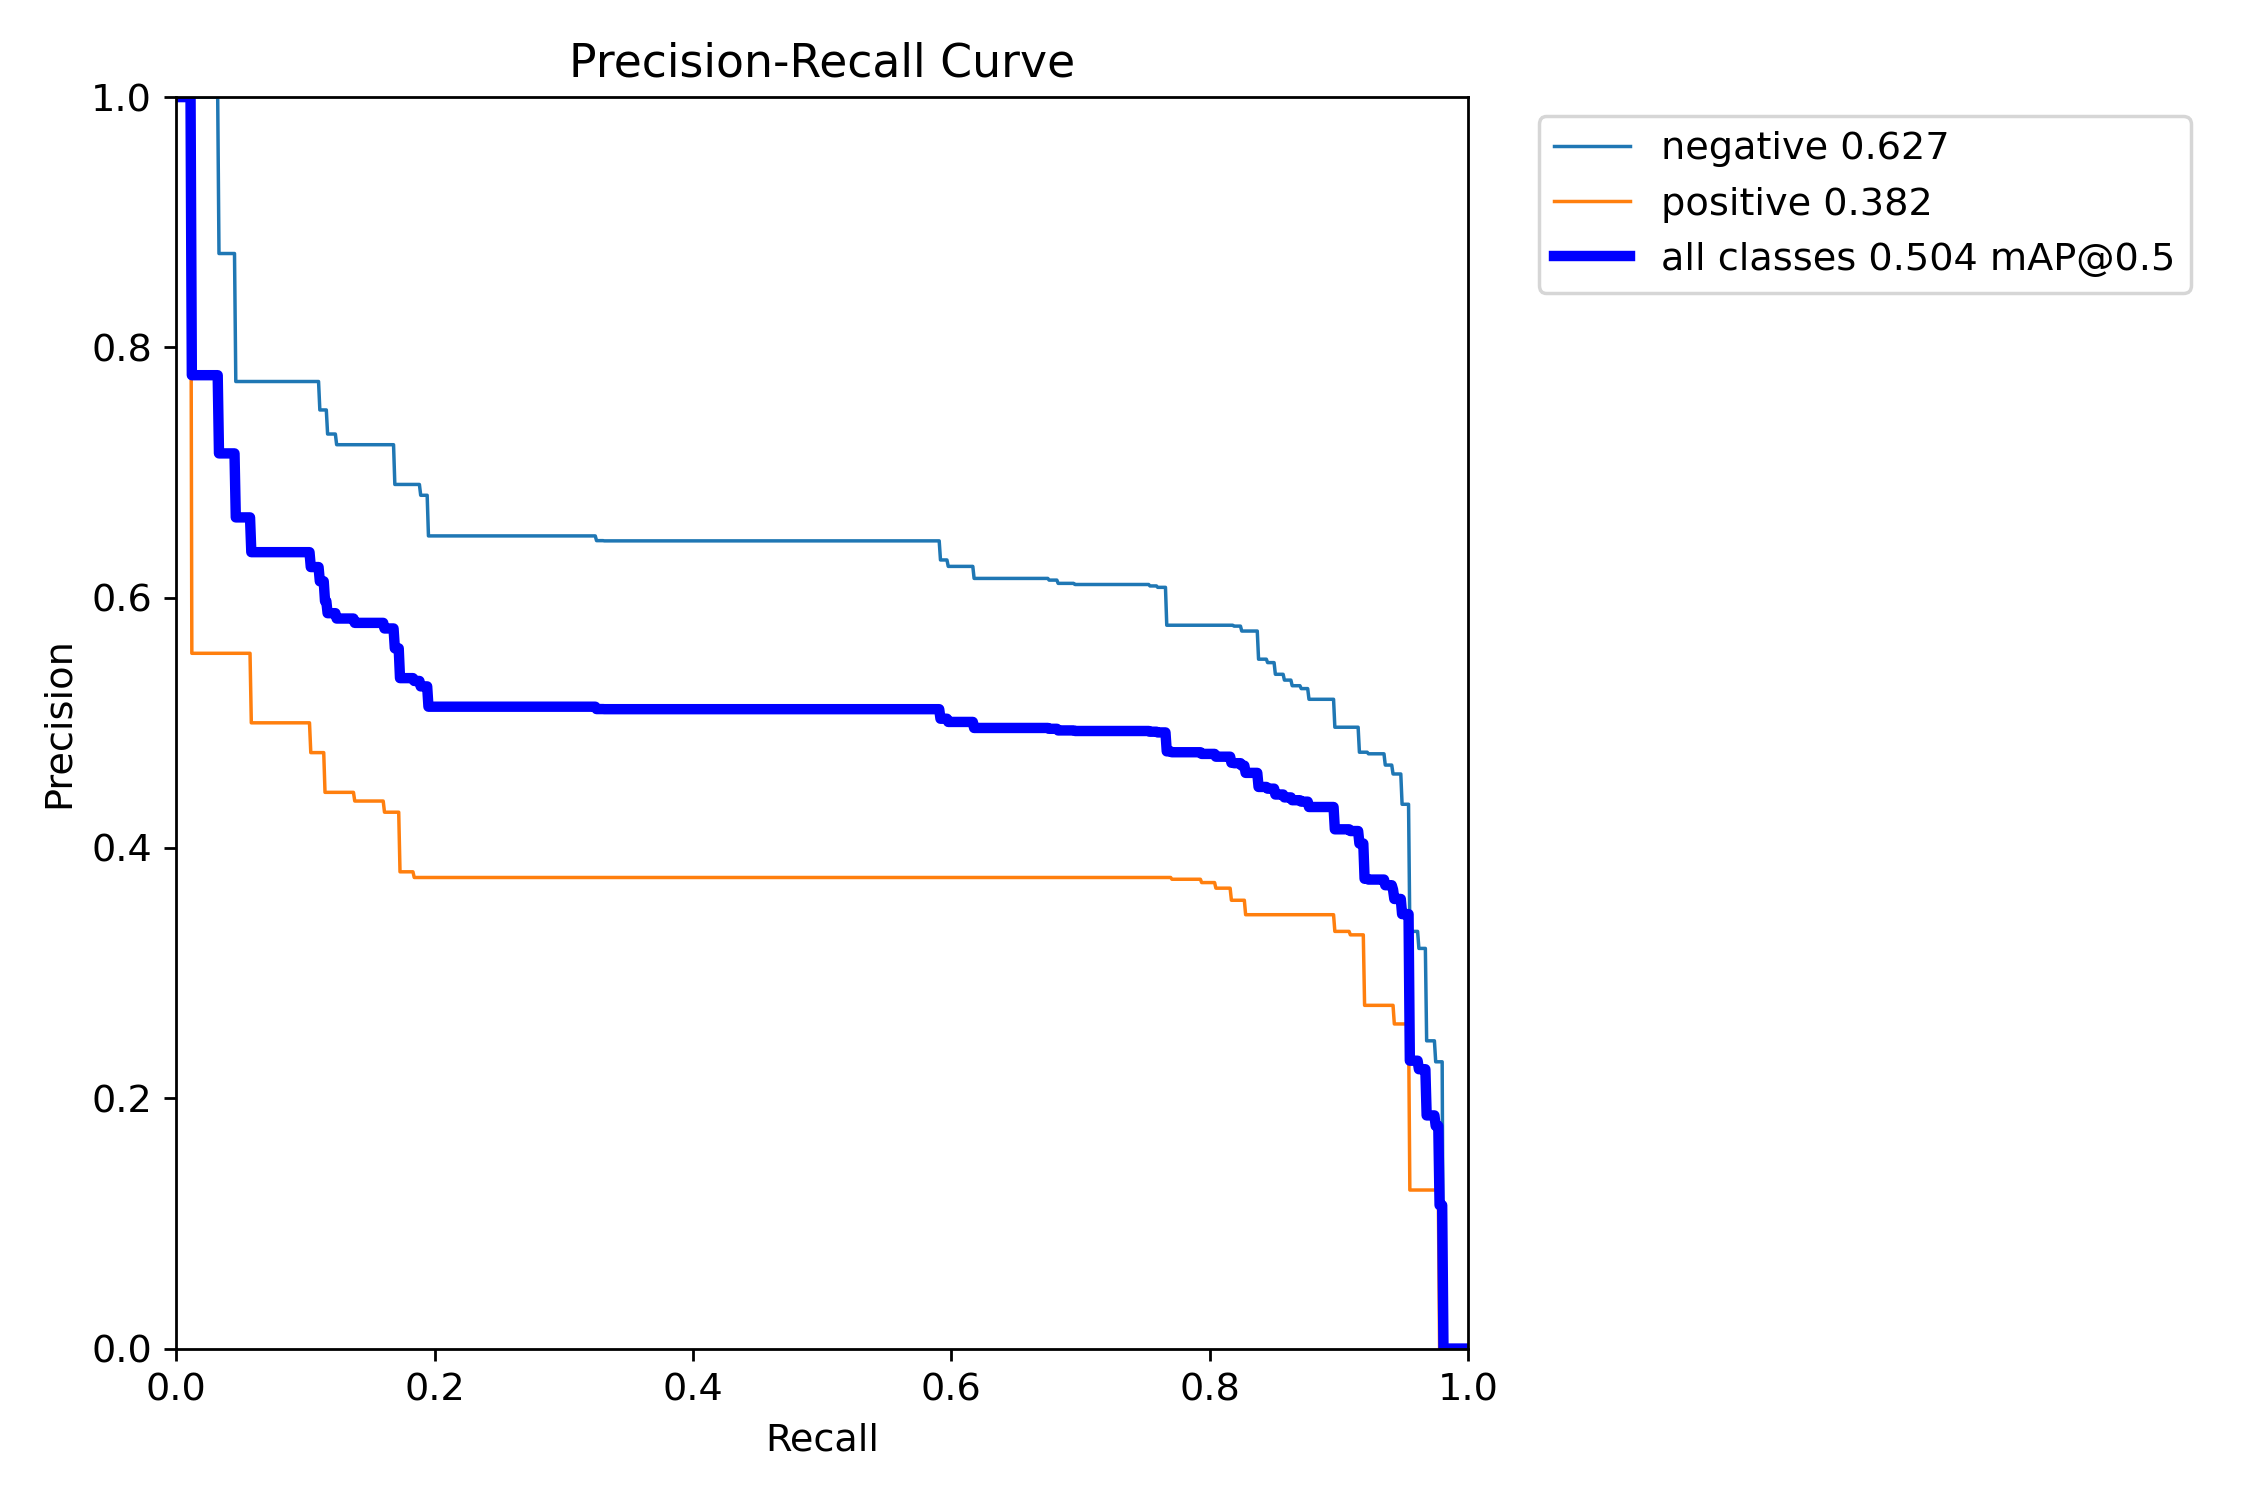


3. F1-GÜVEN (F1-CONFIDENCE) EĞRİSİ
------------------------------------------------------------


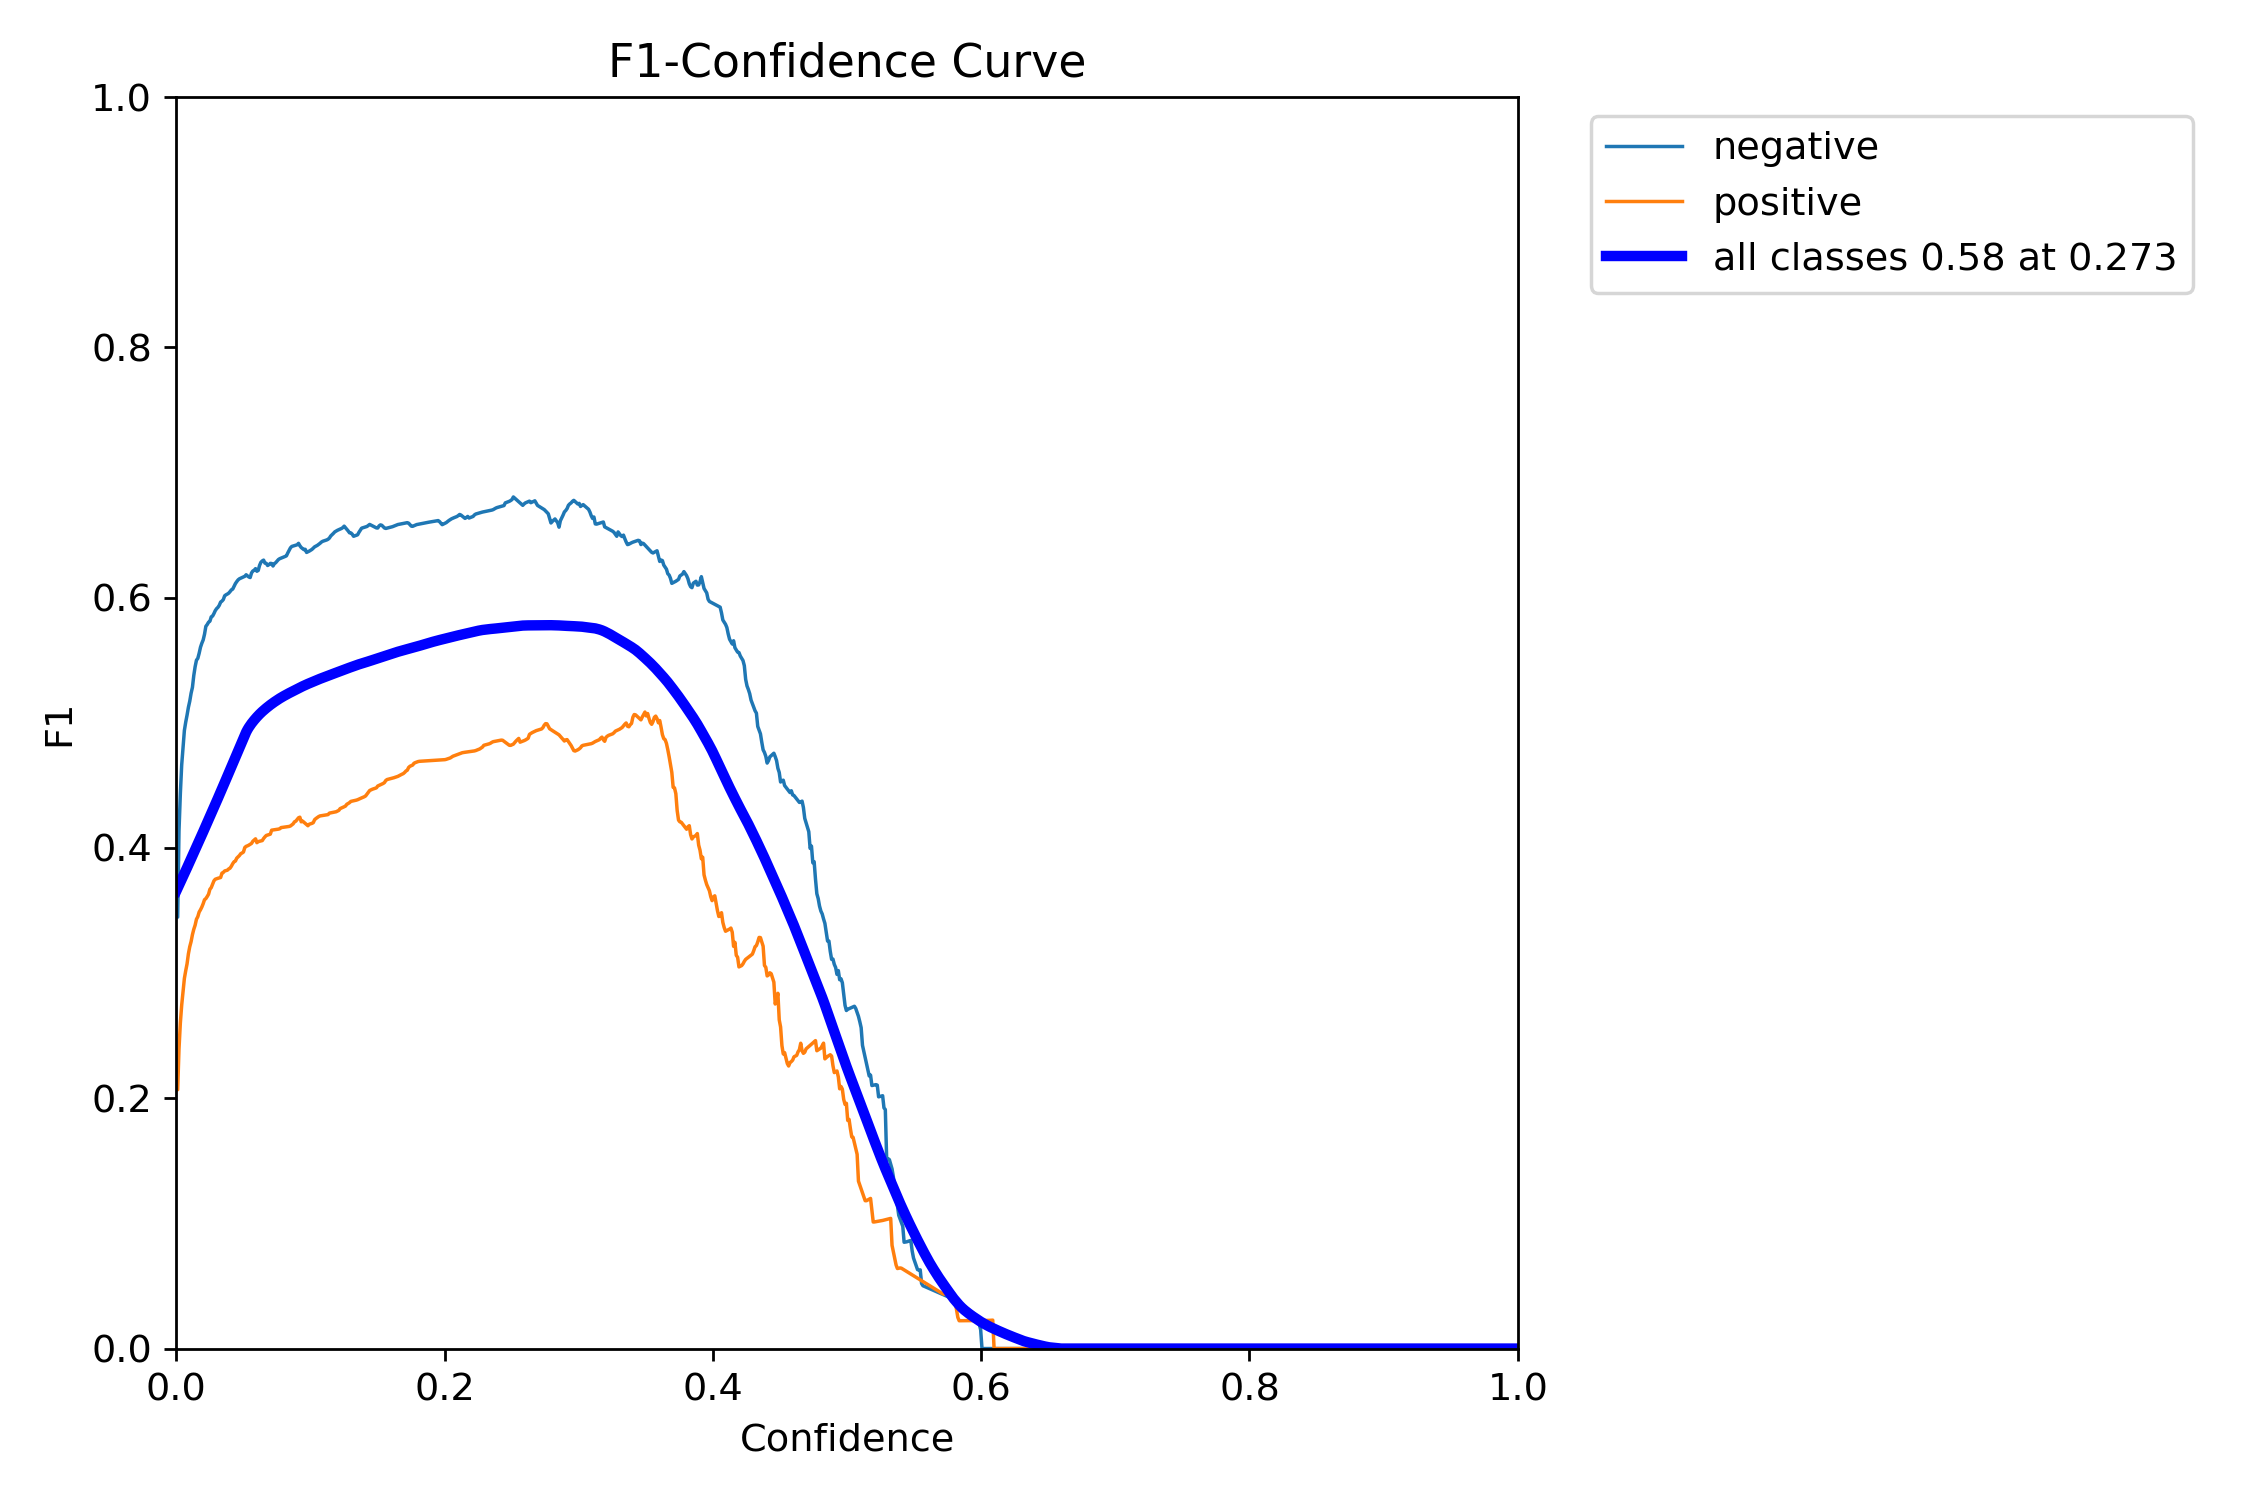


4. EĞİTİM KAYIPLARI VE mAP GRAFİKLERİ (RESULTS)
------------------------------------------------------------


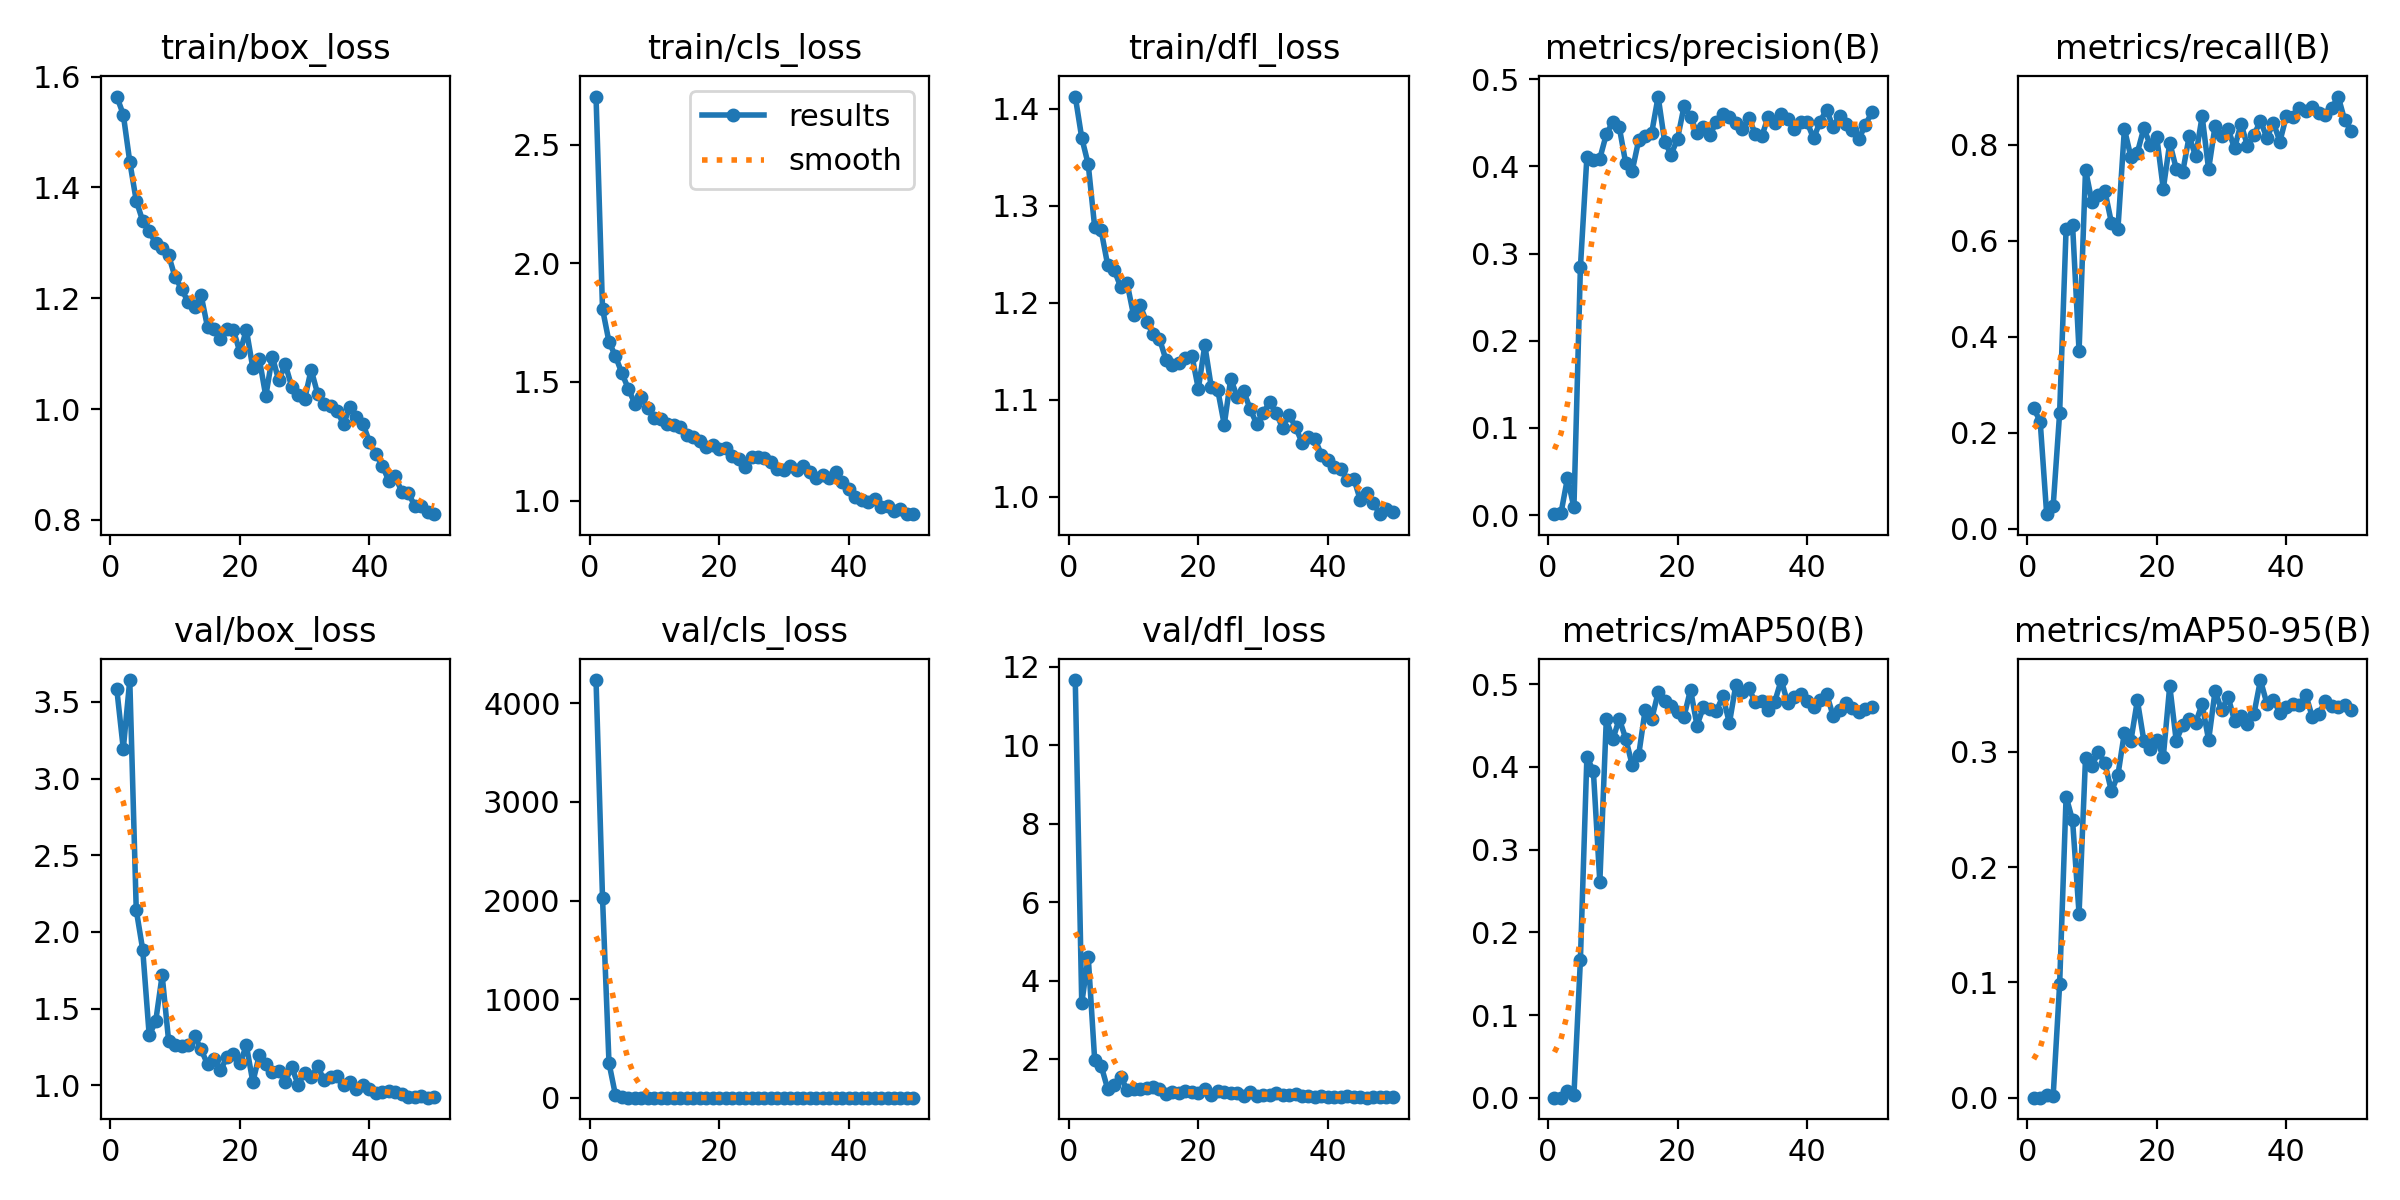

In [22]:
import os
from IPython.display import display, Image

# Grafiklerinizin bulunduğu netleşen dizin
EXP_DIR = '/content/runs/detect/brain_tumor_yolov8/yolov8n_transfer-3'

# Güncellenmiş dosya isimleriyle ödev raporuna eklenecek ana grafikler
grafikler = {
    "confusion_matrix.png": "1. KARIŞIKLIK MATRİSİ (CONFUSION MATRIX)",
    "BoxPR_curve.png": "2. KESİNLİK-DUYARLILIK (PR) EĞRİSİ",
    "BoxF1_curve.png": "3. F1-GÜVEN (F1-CONFIDENCE) EĞRİSİ",
    "results.png": "4. EĞİTİM KAYIPLARI VE mAP GRAFİKLERİ (RESULTS)"
}

# Grafikleri sırayla temiz bir arayüzle ekrana basalım
for dosya, baslik in grafikler.items():
    tam_yol = os.path.join(EXP_DIR, dosya)
    if os.path.exists(tam_yol):
        print(f"\n{baslik}")
        print("-" * 60)
        display(Image(filename=tam_yol, width=550))
    else:
        print(f"\n {dosya} bulunamadı! Lütfen dosya yolunu kontrol edin.")


image 1/3 /content/datasets/brain-tumor/images/val/val_1 (199).jpg: 640x640 (no detections), 16.8ms
image 2/3 /content/datasets/brain-tumor/images/val/val_1 (159).jpg: 640x640 (no detections), 11.9ms
image 3/3 /content/datasets/brain-tumor/images/val/val_1 (204).jpg: 640x640 (no detections), 11.7ms
Speed: 3.5ms preprocess, 13.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/brain_tumor_yolov8/test_sonuclari-3

 Test tamamlandı sonuçları:


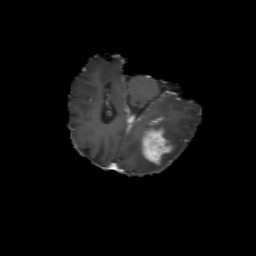

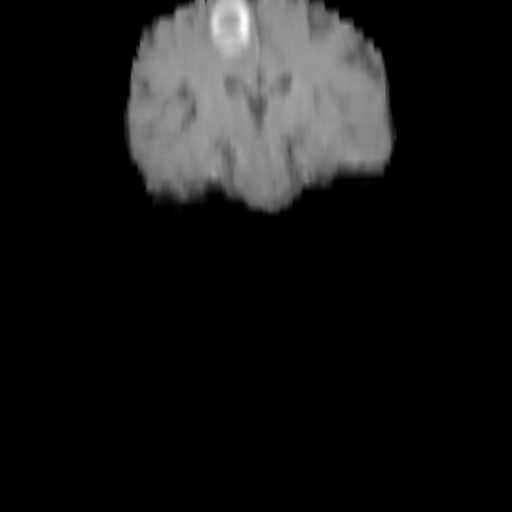

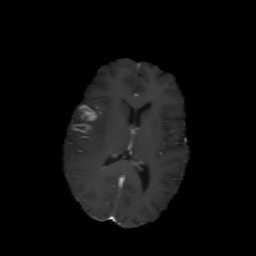

In [23]:
from ultralytics import YOLO
import glob

# Eğitilen en iyi modelin yolu
best_model_path = f'{results_dir}/weights/best.pt'

# Modeli yükle
model = YOLO(best_model_path)

# Doğrulama (val) setinden rastgele 3 adet MR görüntüsü seçelim
val_images = glob.glob('/content/datasets/val/images/*.jpg')[:3]

if not val_images: # Eğer dizin farklıysa alternatif yolu dene
    val_images = glob.glob('/content/datasets/brain-tumor/images/val/*.jpg')[:3]

# Tahmin yap ve sonuçları kaydet
# conf=0.5 parametresi: Modelin emin olma oranı %50'den büyükse kutu çizer
results = model.predict(source=val_images, conf=0.5, save=True, project="brain_tumor_yolov8", name="test_sonuclari")

print("\n Test tamamlandı sonuçları:")

# Tahmin edilen (üzerine kutu çizilen) görüntüleri ekrana yazdır
pred_dir = '/content/runs/detect/brain_tumor_yolov8/test_sonuclari'
pred_images = glob.glob(f'{pred_dir}/*.jpg')

for img_path in pred_images:
    display(Image(filename=img_path, width=400))